# Segmentador de óxido
La idea es **clasificar** cada imagen en base a si presenta una mancha de óxido significativa o no.

## Idea general
1. Se separará la imagen en sus canales RGB, aislando específicamente en canal R.
2. Se hará una cota theta que aisle los píxeles naranjos de la imagen
3. Se aplicará morfología para que las islas de óxido queden suaves, sin ruido, además de eliminar las que son muy pequeñas.
4. Si quedan islas suficientemente grandes en la imagen, ésta se clasifica como "oxidada" y se escribe esta información en un .txt

La idea es que con morfología las islas de óxido pequeñas (fuera de los requisitos del problema) queden fuera. Con esto, luego es trivial que si todavía quedan lagunas de óxido, es porque la imagen presenta óxido digno de ser reportado.

## Librerías
Se usará OpenCV y (si es que es necesario) numpy. No matplotlib, porque OpenCV está mejor optimizado para imágenes.


# Paso 0 - Cargar imágenes y librerías


In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from pathlib import Path

In [2]:
def showcv2image(img):
    #Función para mostrar imágenes de OpenCV en matplotlib
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()

In [ ]:
path0 = str(Path.cwd()) + "/ejemplos/"
path1 = path0 + "B1.jpg"
path2 = path0 + "B2.jpg"
path3 = path0 + "B3.jpg"
path4 = path0 + "B4.jpg"
path5 = path0 + "B5.jpg"
path6 = path0 + "B6.jpg"

In [4]:
# Se cargan las imágenes
img1 = cv2.imread(path1)
img2 = cv2.imread(path2)
img3 = cv2.imread(path3)
img4 = cv2.imread(path4)
img5 = cv2.imread(path5)
img6 = cv2.imread(path6)

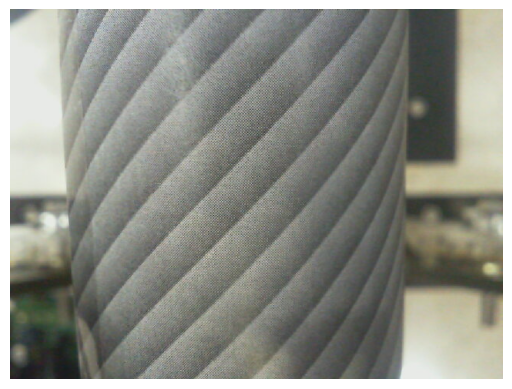

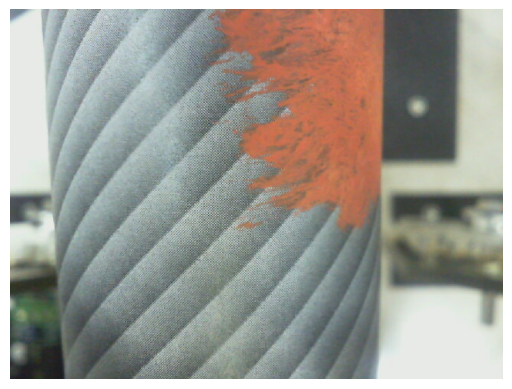

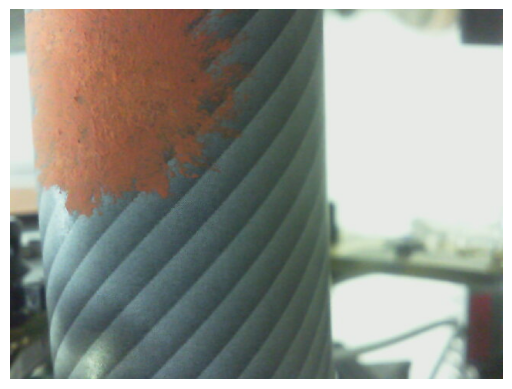

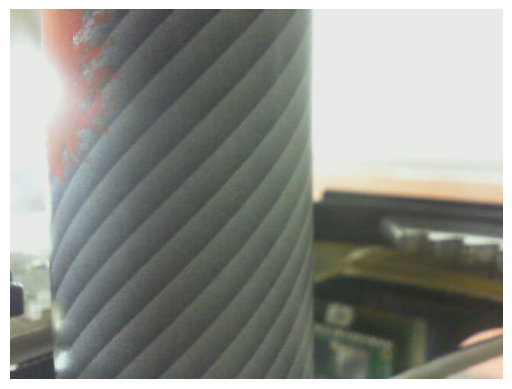

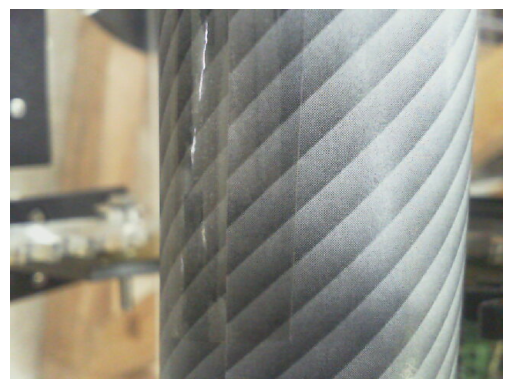

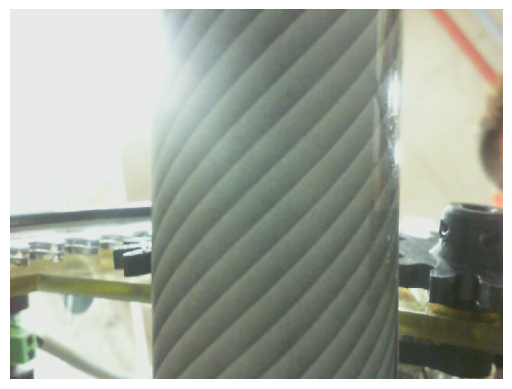

In [5]:
# Se muestran las imágenes para ver que cargaron bien
showcv2image(img1)
showcv2image(img2)
showcv2image(img3)
showcv2image(img4)
showcv2image(img5)
showcv2image(img6)

Visualmente, vemos que las imágenes 2, 3 y 4 deberían ser clasificadas como "óxido" si el clasificador está bien hecho.

# Paso 1 - Separar canales

De aqui en adelante, se ejemplificará con img2

In [19]:
# Convertir la imagen de BGR a HSV
hsv_img = cv2.cvtColor(img2, cv2.COLOR_BGR2HSV)

# Separar los canales HSV
h1, s1, v1 = cv2.split(hsv_img)

Hue


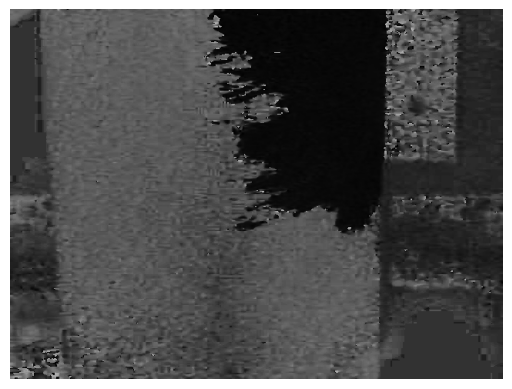

Saturation


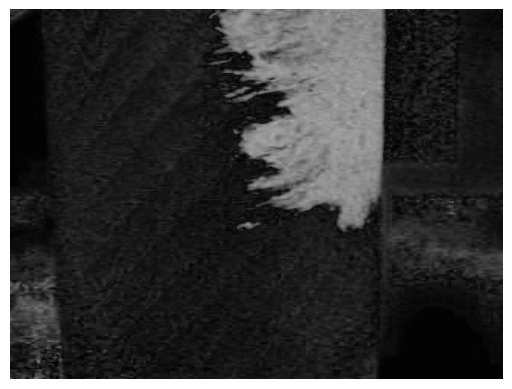

Value


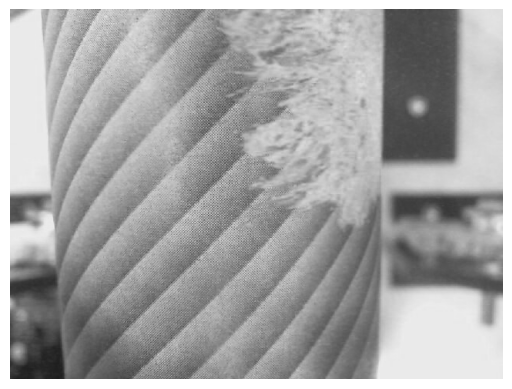

In [20]:
print("Hue")
showcv2image(h1)
print("Saturation")
showcv2image(s1)
print("Value")
showcv2image(v1)

# Paso 2 - Aislar pixeles naranjos


Máscara binaria para tonos naranjas:


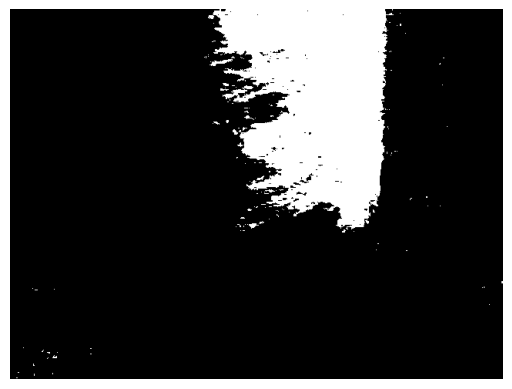

In [21]:
# Definir los rangos de Hue para el color naranja (usando enteros directos)
lower_orange_bound = 2
upper_orange_bound = 12

# Crear la máscara binaria para los tonos naranjas en el canal H1 (1 = naranjo, 0 = nada)
orange_mask = cv2.inRange(h1, lower_orange_bound, upper_orange_bound)

print("Máscara binaria para tonos naranjas:")
showcv2image(orange_mask)

# Paso 3 - Morfología
La idea es hacer:

(Cierre, para juntar clusters de manchas pequeñas)

1. Dilatación kernel s
2. Erosión kernel s

(Apertura, para eliminar manchas)

3. Erosión kernel m
4. Dilatación kernel m

In [22]:
# Kernel pequeño (5x5) para operaciones de cierre (dilatación y erosión)
kernel_s = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (10, 10))

# Kernel mediano (10x10) para operaciones de apertura (erosión y dilatación)
kernel_m = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (30, 30))

Máscara después del Cierre:


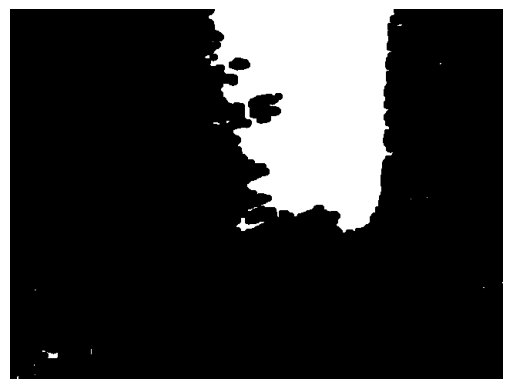

Máscara final después de Apertura:


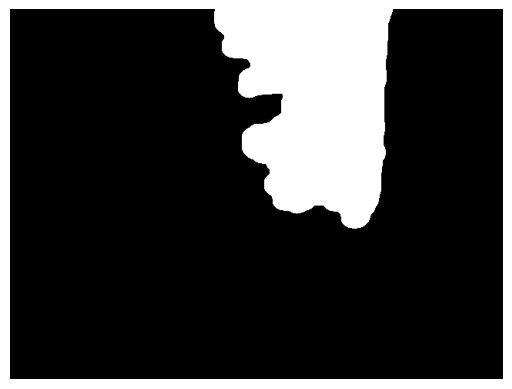

In [23]:
# Aplicar operación de Cierre (Dilatación seguida de Erosión) con kernel_s
closed_mask = cv2.dilate(orange_mask, kernel_s, iterations=1)
closed_mask = cv2.erode(closed_mask, kernel_s, iterations=1)

print("Máscara después del Cierre:")
showcv2image(closed_mask)

# Aplicar operación de Apertura (Erosión seguida de Dilatación) con kernel_m
opened_mask = cv2.erode(closed_mask, kernel_m, iterations=1)
opened_mask = cv2.dilate(opened_mask, kernel_m, iterations=1)

print("Máscara final después de Apertura:")
showcv2image(opened_mask)

Claramente, hay una isla de óxido en la imagen.


# Paso 4 - Clasificación y generación de texto

In [24]:
# Contar el número de píxeles =! 0 en opened_mask
count_nonzero_pixels = cv2.countNonZero(opened_mask)

# Crear la variable booleana
oxido_bool = count_nonzero_pixels > 35

print(f"Número de píxeles con valor 1 en opened_mask: {count_nonzero_pixels}")
print(f"La imagen tiene óxido significativo (más de 5 píxeles): {oxido_bool}")

Número de píxeles con valor 1 en opened_mask: 46977
La imagen tiene óxido significativo (más de 5 píxeles): True


# Función completa
Se combina todo en una sola función

In [ ]:
def clasificar_oxido(img:np.ndarray) -> bool: 
  # Recibe una imagen en formato cv2, retorna un bool
  # Paso 1
  # Convertir la imagen de BGR a HSV
  hsv_img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
  # Separar los canales HSV
  h1, s1, v1 = cv2.split(hsv_img)

  # Paso 2
  # Definir los rangos de Hue para el color naranja (usando enteros directos)
  lower_orange_bound = 2
  upper_orange_bound = 12
  # Crear la máscara binaria para los tonos naranjas en el canal H1 (1 = naranjo, 0 = nada)
  orange_mask = cv2.inRange(h1, lower_orange_bound, upper_orange_bound)

  # Paso 3
  # Kernel pequeño (5x5) para operaciones de cierre (dilatación y erosión)
  kernel_s = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (10, 10))
  # Kernel mediano (10x10) para operaciones de apertura (erosión y dilatación)
  kernel_m = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (30, 30))
  # Aplicar operación de Cierre (Dilatación seguida de Erosión) con kernel_s
  closed_mask = cv2.dilate(orange_mask, kernel_s, iterations=1)
  closed_mask = cv2.erode(closed_mask, kernel_s, iterations=1)
  # Aplicar operación de Apertura (Erosión seguida de Dilatación) con kernel_m
  opened_mask = cv2.erode(closed_mask, kernel_m, iterations=1)
  opened_mask = cv2.dilate(opened_mask, kernel_m, iterations=1)

  # Paso 4
  # Contar el número de píxeles =! 0 en opened_mask
  count_nonzero_pixels = cv2.countNonZero(opened_mask)
  # Crear la variable booleana
  oxido_bool = count_nonzero_pixels > 35

  return oxido_bool

Se combinan todos los inputs en un array y se corre la función para cada imagen, para ver si efectivamente logra el objetivo

In [26]:
img_array = [img1, img2, img3, img4, img5, img6]
pos_array = [10.002, 10.101, 10.433, 10.332, 9.999, 10.301]
paths = [path1, path2, path3, path4, path5, path6]

i = 0
for imagen in img_array:
  if clasificar_oxido(imagen):
    print(str(pos_array[i]) + "," + "O" + "," + paths[i])
  i+=1

10.101,O,/home/grupo3/grupo3_ws/B2.jpg
10.433,O,/home/grupo3/grupo3_ws/B3.jpg
10.332,O,/home/grupo3/grupo3_ws/B4.jpg


Concuerda con la inspección visual, por lo que es suficiente para decir que cumple el objetivo.